In [1]:
## modeling a library of attribution maps as a gaussian mixture 

In [2]:
import h5py
import torch
from pathlib import Path

R = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")
SEQ_ID, LIB_SUFFIX = "peak84030", ""

with h5py.File(R / f"ism{LIB_SUFFIX}/{SEQ_ID}.h5") as f:
    attributions = f["ism_centered"][:]   # (N, 200, 4)

X = torch.tensor(attributions.reshape(attributions.shape[0], -1), dtype=torch.float32, device="cuda")
N, D = X.shape

In [3]:
# mean-field variational Bayes GMM on the GPU (Bishop ch.10, diagonal covariance).
# per-dimension Normal-Gamma prior on (mean, precision), symmetric Dirichlet on weights.
K = 200
torch.manual_seed(0)

# priors  (alpha0 << 1 = sparse Dirichlet -> actively prunes empty components)
alpha0, beta0, a0 = 1e-10, 1.0, 4.0
b0 = a0 * X.var(0)                       # (D,) prior precision = library precision per position/base
m0 = X.mean(0)                           # (D,)
X2 = X**2

# init: K random sequences seed the component means; precision = library precision
seeds = torch.randperm(N, device="cuda")[:K]
alpha = torch.full((K,), alpha0, device="cuda")
beta = torch.full((K,), beta0, device="cuda")
m = X[seeds].clone()                      # (K, D) initial mean per position/base
a = torch.full((K,), a0, device="cuda")
b = a[:, None] * X.var(0)                 # (K, D) -> E[precision] = 1/Var(X) per position/base

for _ in range(200):
    # ---- E-step: responsibilities ----
    E_ln_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())    # (K,)
    E_ln_prec = (torch.digamma(a)[:, None] - torch.log(b)).sum(1)  # (K,)
    E_prec = a[:, None] / b                                        # (K, D)
    # quadratic sum_d E_prec_kd (x_nd - m_kd)^2, expanded to avoid an (N,K,D) tensor
    quad = D / beta + X2 @ E_prec.T - 2 * X @ (E_prec * m).T + (E_prec * m**2).sum(1)  # (N, K)
    log_r = E_ln_pi + 0.5 * E_ln_prec - 0.5 * quad
    r = torch.softmax(log_r, dim=1)

    # ---- M-step: posterior over (pi, mean, precision) ----
    Nk = r.sum(0) + 1e-10                       # (K,)
    xbar = (r.T @ X) / Nk[:, None]             # (K, D)
    Sk = (r.T @ X2) / Nk[:, None] - xbar**2    # weighted variance (K, D)
    alpha = alpha0 + Nk
    beta = beta0 + Nk
    m = (beta0 * m0 + Nk[:, None] * xbar) / beta[:, None]
    a = a0 + Nk / 2
    b = b0 + 0.5 * (Nk[:, None] * Sk + (beta0 * Nk / (beta0 + Nk))[:, None] * (xbar - m0)**2)

# final E-step so labels are consistent with the final means
E_ln_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())
E_ln_prec = (torch.digamma(a)[:, None] - torch.log(b)).sum(1)
E_prec = a[:, None] / b
quad = D / beta + X2 @ E_prec.T - 2 * X @ (E_prec * m).T + (E_prec * m**2).sum(1)
r = torch.softmax(E_ln_pi + 0.5 * E_ln_prec - 0.5 * quad, dim=1)

labels = r.argmax(1).cpu().numpy()
mu_maps = m.reshape(K, D // 4, 4).cpu().numpy()   # per-cluster attribution map

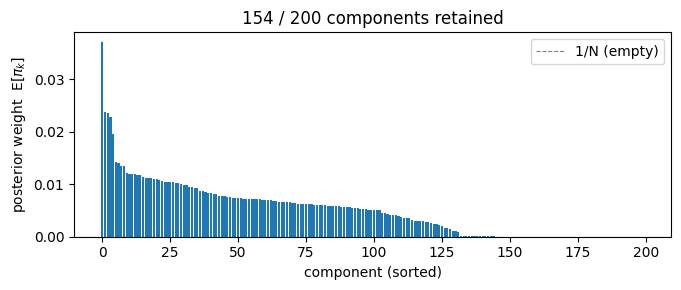

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# VB posterior mixture weights: the Dirichlet prior prunes unused components toward ~0
weights = (alpha / alpha.sum()).cpu().numpy()
order = np.argsort(weights)[::-1]

plt.figure(figsize=(7, 3))
plt.bar(range(K), weights[order])
plt.axhline(1 / N, color="grey", ls="--", lw=0.8, label="1/N (empty)")
plt.xlabel("component (sorted)")
plt.ylabel("posterior weight  E[$\\pi_k$]")
plt.title(f"{(weights > 1/N).sum()} / {K} components retained")
plt.legend()
plt.tight_layout()

In [5]:
# mutant sequences + WT for this library (aligned to the 200-bp attributed window)
mut_path = R / f"mutagenesis_lib/{SEQ_ID}.h5"
with h5py.File(mut_path) as f:
    seqs = f["sequences"][:, 15:215, :]      # (N, 200, 4) one-hot
    wt = f["wt_sequence"][15:215, :]         # (200, 4) one-hot
wt_idx = wt.argmax(1)                         # (200,) reference base per position

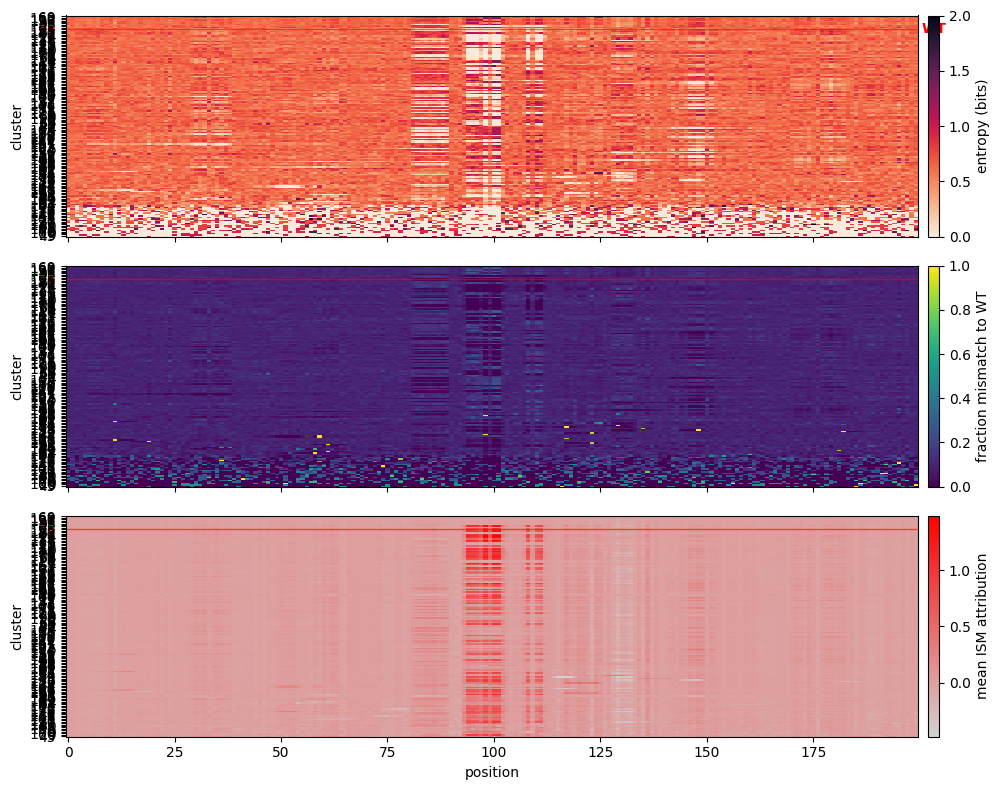

In [6]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
gray_red = LinearSegmentedColormap.from_list("gray_red", ["lightgray", "red"])
rocket_r = sns.color_palette("rocket_r", as_cmap=True)   # SEAM's entropy colormap

# CSM: per-cluster, per-position summaries over the library (retained components only)
keep = order[weights[order] > 1 / N]          # retained components, most-populated first
freqs = np.stack([seqs[labels == k].mean(0) for k in keep])                  # (n_keep, 200, 4)

entropy = -np.nansum(freqs * np.log2(freqs + 1e-12), axis=2)                 # (n_keep, 200)
mismatch = 1 - freqs[:, np.arange(200), wt_idx]                             # fraction != WT base

proj = (attributions * seqs).sum(-1)                                         # ISM attr at each seq's base
attr_sig = np.stack([proj[labels == k].mean(0) for k in keep])              # (n_keep, 200)

wt_label = labels[0]                             # WT is index 0 by convention (VAE_gmm)
wt_pos = list(keep).index(wt_label)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, M, cmap, label in [(axes[0], entropy, rocket_r, "entropy (bits)"),
                           (axes[1], mismatch, "viridis", "fraction mismatch to WT"),
                           (axes[2], attr_sig, gray_red, "mean ISM attribution")]:
    im = ax.imshow(M, aspect="auto", cmap=cmap, interpolation="nearest")
    ax.set_ylabel("cluster")
    ax.set_yticks(range(len(keep)))
    ax.set_yticklabels(keep)
    ax.axhline(wt_pos, color="red", lw=1, alpha=0.6)
    ax.get_yticklabels()[wt_pos].set_color("red")
    fig.colorbar(im, ax=ax, label=label, pad=0.01)
axes[0].annotate("WT", (1.005, wt_pos), xycoords=("axes fraction", "data"),
                 color="red", va="center", fontweight="bold")
axes[2].set_xlabel("position")
plt.tight_layout()

WT cluster 18: 1223 seqs, weight 0.012
cos(WT map, its mean 18): 0.990   most-WT-like cluster 18 (cos 0.990)

   k   size   E[lnpi]  0.5E[lnL]   -0.5*dist      logr
  18   1223     -4.40    2944.81     -157.06   2783.34
  18   1223     -4.40    2944.81     -157.06   2783.34


NameError: name 'fast_logo' is not defined

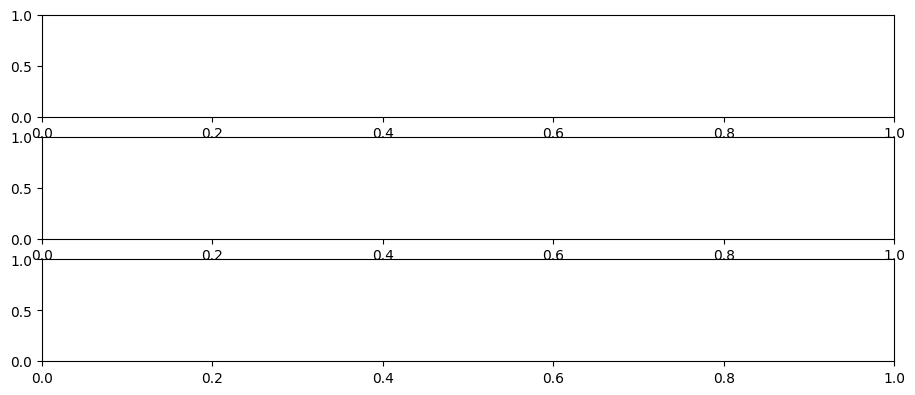

In [7]:
# diagnose: is WT's assigned cluster the one whose MEAN looks like WT? if not, WHY?
wt_members = np.where(labels == wt_label)[0]
wt_map = attributions[0].ravel()
cms = mu_maps.reshape(K, -1)
cos = cms @ wt_map / (np.linalg.norm(cms, axis=1) * np.linalg.norm(wt_map) + 1e-12)
best = int(cos.argmax())

print(f"WT cluster {wt_label}: {len(wt_members)} seqs, weight {weights[wt_label]:.3f}")
print(f"cos(WT map, its mean {wt_label}): {cos[wt_label]:.3f}   most-WT-like cluster {best} (cos {cos.max():.3f})")

# decompose log-responsibility of the WT point (index 0) for the two clusters
x0 = X[0]
q = D / beta + (E_prec * (x0[None] - m) ** 2).sum(1)      # Mahalanobis-like distance term (K,)
term_pi   = E_ln_pi                                       # weight pull
term_prec = 0.5 * E_ln_prec                              # log-precision (cluster tightness)
term_dist = -0.5 * q
logr = term_pi + term_prec + term_dist
print(f"\n{'k':>4} {'size':>6} {'E[lnpi]':>9} {'0.5E[lnL]':>10} {'-0.5*dist':>11} {'logr':>9}")
for k in [wt_label, best]:
    print(f"{k:>4} {int((labels==k).sum()):>6} {term_pi[k].item():>9.2f} "
          f"{term_prec[k].item():>10.2f} {term_dist[k].item():>11.2f} {logr[k].item():>9.2f}")

fig, ax = plt.subplots(3, 1, figsize=(11, 4.5))
fast_logo(attributions[0], ax=ax[0]);       ax[0].set_title("true WT ISM map (attributions[0])")
fast_logo(mu_maps[wt_label], ax=ax[1]);     ax[1].set_title(f"WT's assigned cluster {wt_label} mean")
fast_logo(mu_maps[best], ax=ax[2]);         ax[2].set_title(f"most-WT-like cluster {best} mean")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout()